In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import mplfinance as mpf
from pathlib import Path
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests


## Данные


In [2]:
news_old = pd.read_parquet(Path('news_descriptions/news_collection_old.parquet'))
print(f"Новостей: {len(news_old)}")
print(f"Период:   {news_old['date'].min()} — {news_old['date'].max()}")


Новостей: 79705
Период:   2009-06-19 00:00:00 — 2024-12-09 00:00:00


## Инференс

Загружаем дообученную модель из `models/rubert-financial-sentiment/`.
Результаты кэшируются в `news_sentiment_rubert.parquet` — повторный запуск ячейки
просто читает файл, не запуская модель заново.


In [3]:
PRED_PATH = Path("news_sentiment_rubert.parquet")
MODEL_DIR = Path("models/rubert-financial-sentiment")

if PRED_PATH.exists():
    scored = pd.read_parquet(PRED_PATH)
    print(f"Loaded from cache: {len(scored)} records")
else:
    from transformers import pipeline as hf_pipeline

    clf = hf_pipeline(
        "text-classification",
        model=str(MODEL_DIR),
        device="mps" if torch.backends.mps.is_available() else (0 if torch.cuda.is_available() else -1),
        truncation=True,
        max_length=256,
    )

    all_texts  = news_old["body"].fillna("").str.strip('"').tolist()
    full_preds = clf(all_texts, batch_size=64)

    sent_map = {"NEGATIVE": -1, "NEUTRAL": 0, "POSITIVE": 1}
    dt = pd.to_datetime(news_old["date"], errors="coerce")
    scored = pd.DataFrame({
        "date":      dt.dt.normalize(),
        "time":      dt.dt.strftime("%H:%M:%S"),
        "sentiment": [sent_map.get(p["label"], 0) for p in full_preds],
    })
    scored.to_parquet(PRED_PATH, index=False)
    print(f"Inference done. Saved {len(scored)} predictions → {PRED_PATH}")

print(f"Период: {scored['date'].min().date()} — {scored['date'].max().date()}")
scored["sentiment"].value_counts().rename({-1: "NEGATIVE", 0: "NEUTRAL", 1: "POSITIVE"})


Loaded from cache: 79705 records
Период: 2009-06-19 — 2024-12-09


sentiment
POSITIVE    40595
NEGATIVE    24809
NEUTRAL     14301
Name: count, dtype: int64

## Гипотеза 1

Агрегированный дневной сентимент новостей, вычисленный дообученным RuBERT,
имеет статистически значимую корреляцию с динамикой IMOEX.

$$S_t = \frac{P_t - N_t}{P_t + N_t + \varepsilon}, \quad \varepsilon = 1$$


### Дневной индекс сентимента

Новости после 18:30 относятся к следующему торговому дню.


In [4]:
sn = scored.copy()
sn["dt"] = pd.to_datetime(sn["date"].astype(str) + " " + sn["time"].astype(str), errors="coerce")
sn["trade_date"] = sn["dt"].dt.normalize()
sn.loc[sn["dt"].dt.hour >= 18, "trade_date"] += pd.Timedelta(days=1)

eps = 1
daily = (
    sn.groupby("trade_date")["sentiment"]
    .agg(P=lambda x: (x == 1).sum(), N=lambda x: (x == -1).sum(), total="count")
    .reset_index()
    .rename(columns={"trade_date": "date"})
)
daily["S"] = (daily["P"] - daily["N"]) / (daily["P"] + daily["N"] + eps)
print(f"Дней с новостями: {len(daily)}")
daily.head()


Дней с новостями: 1967


,date,P,N,total,S
0,2009-06-19,0,1,1,-0.5
1,2011-01-21,1,0,1,0.5
2,2011-04-05,0,1,1,-0.5
3,2011-04-06,1,0,1,0.5
4,2011-04-07,0,1,1,-0.5


### Котировки IMOEX

Выходные и праздники → ближайший торговый день вперёд.


In [5]:
moex = pd.read_csv(Path("MOEX.csv"), encoding="cp1251", sep=";")
moex["date"] = pd.to_datetime(moex["TRADEDATE"], dayfirst=True)
for col in ["OPEN", "HIGH", "LOW", "CLOSE"]:
    moex[col] = moex[col].str.replace(",", ".").astype(float)
moex = moex[["date", "OPEN", "HIGH", "LOW", "CLOSE"]].rename(
    columns={"OPEN": "open", "HIGH": "high", "LOW": "low", "CLOSE": "close"}
).sort_values("date").reset_index(drop=True)
moex["return"]    = moex["close"].pct_change()
moex["range_pct"] = (moex["high"] - moex["low"]) / moex["low"] * 100

trading_set = set(moex["date"])

def snap(d):
    while d not in trading_set:
        d += pd.Timedelta(days=1)
    return d

daily["date"] = daily["date"].apply(snap)
daily_agg = (
    daily.groupby("date")
    .agg(P=("P", "sum"), N=("N", "sum"), total=("total", "sum"))
    .reset_index()
)
daily_agg["S"] = (daily_agg["P"] - daily_agg["N"]) / (daily_agg["P"] + daily_agg["N"] + eps)

merged = moex.merge(daily_agg[["date", "S"]], on="date", how="inner").dropna(subset=["return", "S"])
merged["S_lag1"] = merged["S"].shift(1)
merged["abs_S"]  = merged["S"].abs()
merged = merged.dropna(subset=["S_lag1"]).reset_index(drop=True)

print(f"Пересечение: {len(merged)} торговых дней")
print(f"Период: {merged['date'].min().date()} — {merged['date'].max().date()}")
merged[["date", "close", "range_pct", "S", "return"]].head()


Пересечение: 686 торговых дней
Период: 2022-01-12 — 2024-12-09


,date,close,return,S,S_lag1
0,2022-01-12,3829.95,0.011798,0.169492,0.156863
1,2022-01-13,3674.73,-0.040528,0.437500,0.169492
2,2022-01-14,3596.98,-0.021158,-0.533333,0.437500
3,2022-01-17,3560.35,-0.010184,-0.277778,-0.533333
4,2022-01-18,3328.94,-0.064996,-0.769231,-0.277778


### Корреляционный анализ

- **одновременный** — $S_t$ vs $R_t$
- **лаговый** — $S_{t-1}$ vs $R_t$: предсказывает ли вчерашний сентимент сегодняшнюю доходность?


In [6]:
pairs = [
    ("S_t vs R_t",     "S",      "return"),
    ("S_{t-1} vs R_t", "S_lag1", "return"),
]

rows = []
for label, x_col, y_col in pairs:
    r,   p_r   = stats.pearsonr(merged[x_col], merged[y_col])
    rho, p_rho = stats.spearmanr(merged[x_col], merged[y_col])
    rows.append({"Вариант": label,
                 "Pearson r":  round(r,   4), "p (Pearson)":  round(p_r,   4),
                 "Spearman ρ": round(rho, 4), "p (Spearman)": round(p_rho, 4)})

pd.DataFrame(rows)


,Вариант,Pearson r,p (Pearson),Spearman ρ,p (Spearman)
0,S_t vs R_t,0.2095,0.0000,0.2409,0.0000
1,S_{t-1} vs R_t,0.0581,0.1285,0.0360,0.3464


In [7]:
print("Тест Грейнджера: S → R (лаги 1–5)\n")
grangercausalitytests(merged[["return", "S"]].dropna(), maxlag=5, verbose=True)


Тест Грейнджера: S → R (лаги 1–5)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.1095  , p=0.0241  , df_denom=682, df_num=1
ssr based chi2 test:   chi2=5.1320  , p=0.0235  , df=1
likelihood ratio test: chi2=5.1128  , p=0.0237  , df=1
parameter F test:         F=5.1095  , p=0.0241  , df_denom=682, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.3481  , p=0.0133  , df_denom=679, df_num=2
ssr based chi2 test:   chi2=8.7602  , p=0.0125  , df=2
likelihood ratio test: chi2=8.7046  , p=0.0129  , df=2
parameter F test:         F=4.3481  , p=0.0133  , df_denom=679, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.9931  , p=0.0303  , df_denom=676, df_num=3
ssr based chi2 test:   chi2=9.0721  , p=0.0283  , df=3
likelihood ratio test: chi2=9.0124  , p=0.0291  , df=3
parameter F test:         F=2.9931  , p=0.0303  , df_denom=676, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F t

/Users/artyom-olenev/Projects/news_analyzer/.venv/lib/python3.14/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(5.109502889957003),
    np.float64(0.02410961703652851),
    np.float64(682.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(5.131978709121037),
    np.float64(0.02348893530601342),
    np.int64(1)),
   'lrtest': (np.float64(5.112849953129626),
    np.float64(0.023749277039978138),
    np.int64(1)),
   'params_ftest': (np.float64(5.109502889957021),
    np.float64(0.02410961703652827),
    np.float64(682.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(4.34809459750125),
    np.float64(0.013293417465101343),
    np.float64(679.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(8.760225934288231),
    np.float64(0.012523943747000584),
    np.int64(2)),
   'lrtest': (np.float64(8.704602724288634),
    np.float64(0.012877143483366455),
    np.int64(2)),
   'params_ftest': (np.float64(4.348094597501124),
    np.float64(0.013293417465103008),
    np.float64(679.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
  

In [8]:
merged["pred"]   = (merged["S_lag1"] > 0).astype(int)
merged["actual"] = (merged["return"] > 0).astype(int)
acc = (merged["pred"] == merged["actual"]).mean()
print(f"Направленная точность: {acc:.1%}")


Направленная точность: 53.8%


### Визуализация


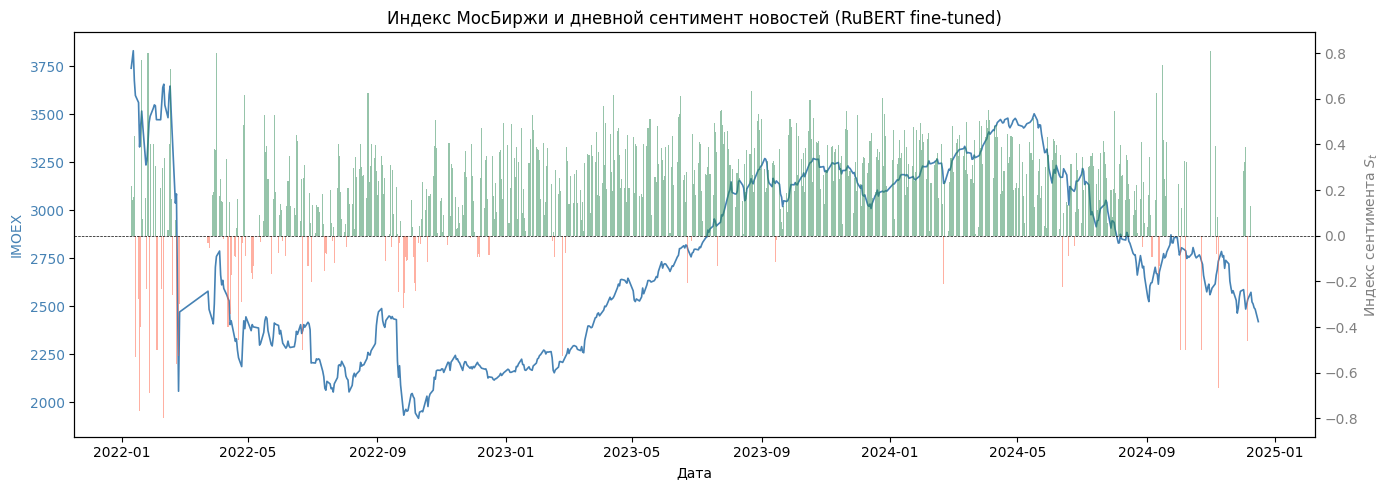

In [9]:
moex_mpf = moex.set_index("date")[["open", "high", "low", "close"]].copy()
moex_mpf.columns = ["Open", "High", "Low", "Close"]
moex_mpf.index.name = "Date"

sent_aligned = daily_agg.set_index("date")["S"].reindex(moex_mpf.index).fillna(0)

overlap_start = daily_agg["date"].min()
overlap_end   = daily_agg["date"].max()
mask = (moex_mpf.index >= overlap_start) & (moex_mpf.index <= overlap_end)

sub_ohlc = moex_mpf[mask]
sub_sent = sent_aligned[mask]

bar_colors = ["seagreen" if v >= 0 else "tomato" for v in sub_sent]
ap = mpf.make_addplot(sub_sent, panel=1, type="bar", color=bar_colors, ylabel="$S_t$")

mpf.plot(
    sub_ohlc,
    type="candle",
    style="yahoo",
    figsize=(16, 8),
    title="IMOEX (свечи) + дневной сентимент новостей (RuBERT fine-tuned)",
    addplot=ap,
    panel_ratios=(3, 1),
    tight_layout=True,
)


In [10]:
r_s,   p_rs   = stats.pearsonr(merged["S"],      merged["return"])
rho_s, p_rhos = stats.spearmanr(merged["S"],      merged["return"])
r_l,   p_rl   = stats.pearsonr(merged["S_lag1"],  merged["return"])
rho_l, p_rhol = stats.spearmanr(merged["S_lag1"], merged["return"])

sig = lambda p: "✓ значимо" if p < 0.05 else "✗ незначимо"

pd.DataFrame([
    ["Pearson r",  "S_t vs R_t",     f"{r_s:.4f}",   f"{p_rs:.4f}",  sig(p_rs)],
    ["Spearman ρ", "S_t vs R_t",     f"{rho_s:.4f}", f"{p_rhos:.4f}", sig(p_rhos)],
    ["Pearson r",  "S_{t-1} vs R_t", f"{r_l:.4f}",   f"{p_rl:.4f}",  sig(p_rl)],
    ["Spearman ρ", "S_{t-1} vs R_t", f"{rho_l:.4f}", f"{p_rhol:.4f}", sig(p_rhol)],
    ["Точность",   "S_{t-1} → dir",  f"{acc:.1%}",   "—",            "Выше 50%" if acc > 0.5 else "На уровне случайного"],
], columns=["Метрика", "Вариант", "Значение", "p-value", "Вывод"])


,Метрика,Вариант,Значение,p-value,Вывод
0,Pearson r,S_t vs R_t,0.2095,0.0000,✓ значимо
1,Spearman ρ,S_t vs R_t,0.2409,0.0000,✓ значимо
2,Pearson r,S_{t-1} vs R_t,0.0581,0.1285,✗ незначимо
3,Spearman ρ,S_{t-1} vs R_t,0.0360,0.3464,✗ незначимо
4,Точность,S_{t-1} → dir,53.8%,—,Выше 50%


---
## Детальный анализ


### Scatter: сентимент vs доходность IMOEX


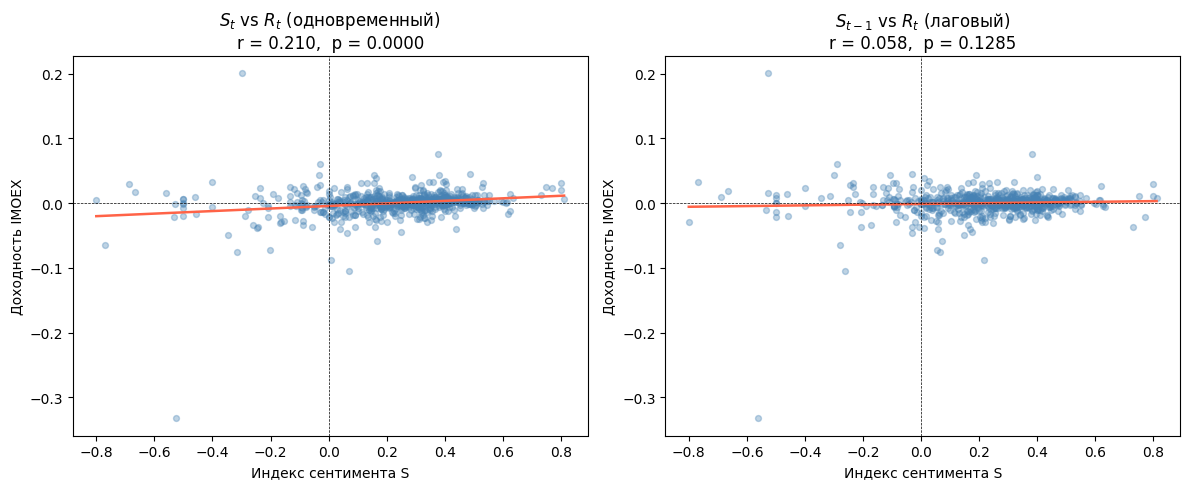

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (title, x_col) in zip(axes, [
    ("$S_t$ vs $R_t$ (одновременный)", "S"),
    ("$S_{t-1}$ vs $R_t$ (лаговый)",   "S_lag1"),
]):
    x, y = merged[x_col], merged["return"]
    ax.scatter(x, y, alpha=0.35, s=18, color="steelblue")
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 200)
    ax.plot(xs, m * xs + b, color="tomato", linewidth=1.8)
    r, p = stats.pearsonr(x, y)
    ax.set_title(f"{title}" + "\n" + f"r = {r:.3f},  p = {p:.4f}")
    ax.set_xlabel("Индекс сентимента S")
    ax.set_ylabel("Доходность IMOEX")
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="black", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()


### Распределение доходностей по тональности дня


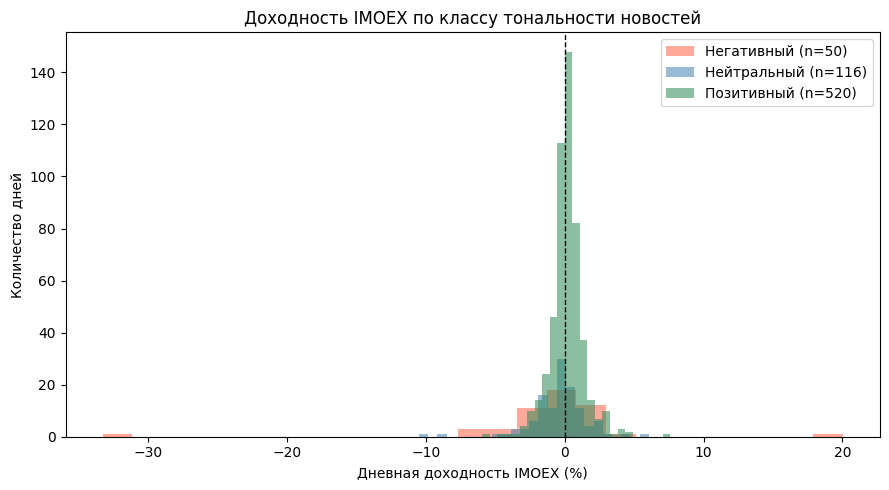

,mean,median,count
s_cat,,,
Негативный,-1.066%,-0.368%,50
Нейтральный,-0.422%,-0.251%,116
Позитивный,0.176%,0.154%,520


In [12]:
merged["s_cat"] = pd.cut(
    merged["S"],
    bins=[-np.inf, -0.1, 0.1, np.inf],
    labels=["Негативный", "Нейтральный", "Позитивный"],
)

palette = {"Негативный": "tomato", "Нейтральный": "steelblue", "Позитивный": "seagreen"}

fig, ax = plt.subplots(figsize=(9, 5))
for cat, grp in merged.groupby("s_cat", observed=True):
    ax.hist(grp["return"] * 100, bins=25, alpha=0.55,
            label=f"{cat} (n={len(grp)})", color=palette[cat])

ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Дневная доходность IMOEX (%)")
ax.set_ylabel("Количество дней")
ax.legend()
ax.set_title("Доходность IMOEX по классу тональности новостей")
plt.tight_layout()
plt.show()

merged.groupby("s_cat", observed=True)["return"].agg(
    mean=lambda x: f"{x.mean()*100:.3f}%",
    median=lambda x: f"{x.median()*100:.3f}%",
    count="count",
)


### Скользящая корреляция (окно 30 дней)

Показывает, насколько стабильна связь сентимента и доходности во времени.


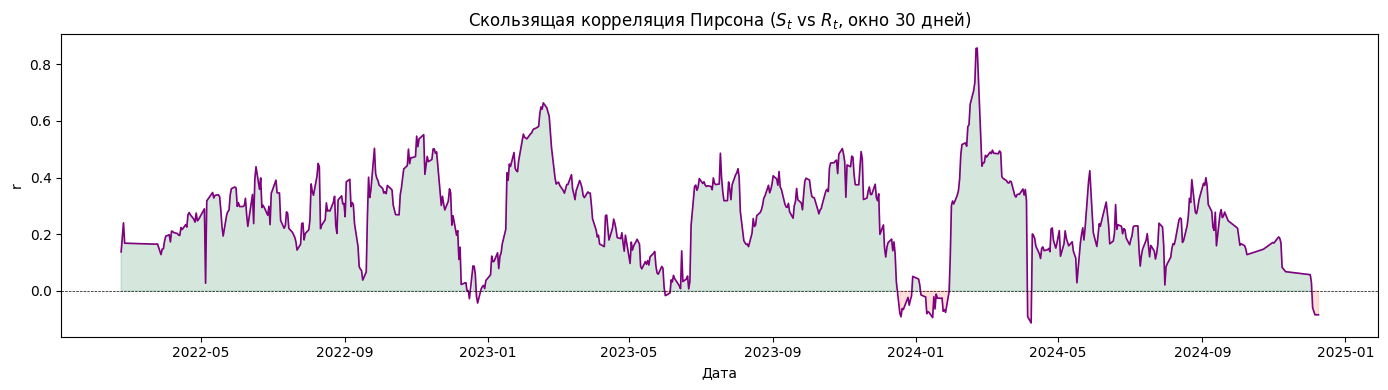

In [13]:
window = 30
roll_r = merged.set_index("date")["S"].rolling(window).corr(
    merged.set_index("date")["return"]
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(roll_r.index, roll_r.values, color="purple", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.fill_between(roll_r.index, roll_r.values, 0,
                where=roll_r.values > 0, alpha=0.2, color="seagreen")
ax.fill_between(roll_r.index, roll_r.values, 0,
                where=roll_r.values < 0, alpha=0.2, color="tomato")
ax.set_title(f"Скользящая корреляция Пирсона ($S_t$ vs $R_t$, окно {window} дней)")
ax.set_ylabel("r")
ax.set_xlabel("Дата")
plt.tight_layout()
plt.show()


### Стратегия на сентименте vs Buy & Hold

Простая стратегия: лонг в IMOEX, если $S_{t-1} > 0$, иначе выход в кэш.


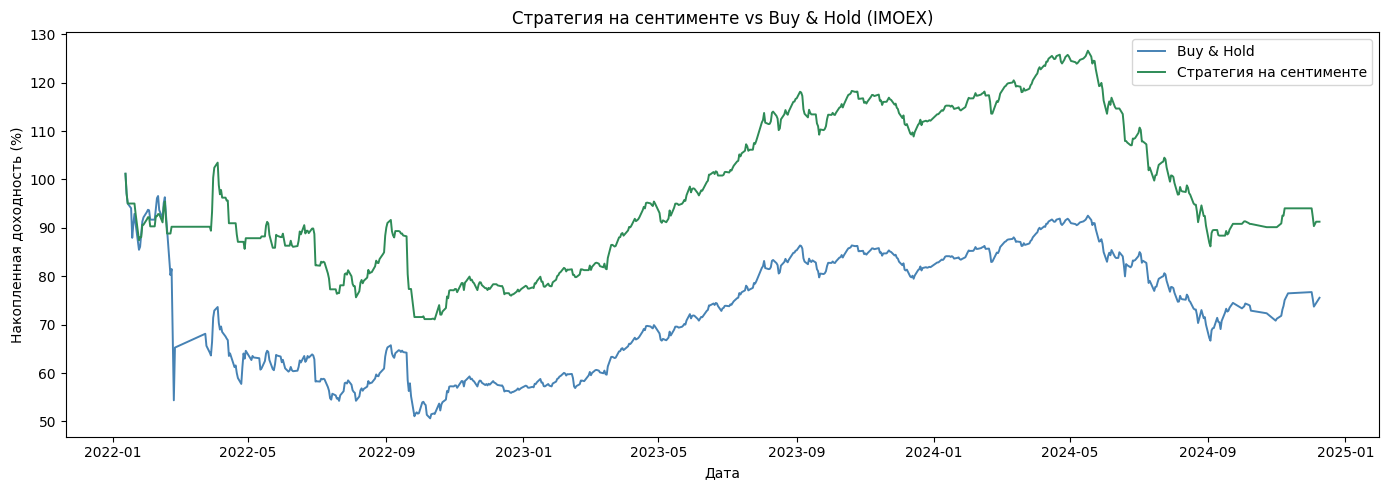

Buy & Hold:          -24.4%
Стратегия сентимент: -8.7%


In [14]:
strat = merged.copy()
strat["pos"] = (strat["S_lag1"] > 0).astype(int)
strat["r_strat"] = strat["pos"] * strat["return"]

strat["cum_bah"]   = (1 + strat["return"]).cumprod()
strat["cum_strat"] = (1 + strat["r_strat"]).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(strat["date"], strat["cum_bah"]   * 100, color="steelblue",
        linewidth=1.4, label="Buy & Hold")
ax.plot(strat["date"], strat["cum_strat"] * 100, color="seagreen",
        linewidth=1.4, label="Стратегия на сентименте")
ax.set_ylabel("Накопленная доходность (%)")
ax.set_xlabel("Дата")
ax.legend()
ax.set_title("Стратегия на сентименте vs Buy & Hold (IMOEX)")
plt.tight_layout()
plt.show()

final_bah   = strat["cum_bah"].iloc[-1]
final_strat = strat["cum_strat"].iloc[-1]
print(f"Buy & Hold:          {(final_bah   - 1)*100:+.1f}%")
print(f"Стратегия сентимент: {(final_strat - 1)*100:+.1f}%")


### Свечи IMOEX и сентимент новостей

Нижняя панель — дневной индекс $S_t$: зелёный означает преобладание позитива, красный — негатива.


/Users/artyom-olenev/Projects/news_analyzer/.venv/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


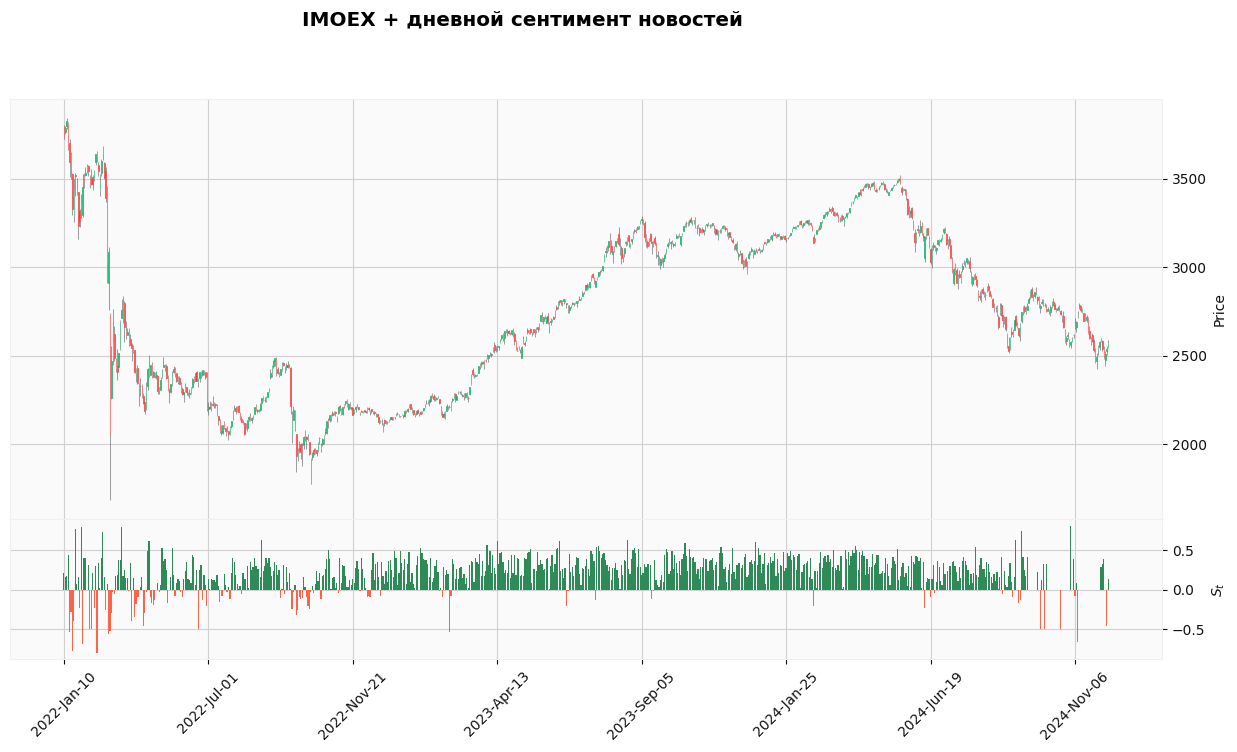

In [15]:
moex_ohlc = pd.read_csv(Path("MOEX.csv"), encoding="cp1251", sep=";")
moex_ohlc["date"] = pd.to_datetime(moex_ohlc["TRADEDATE"], dayfirst=True)
for col in ["OPEN", "HIGH", "LOW", "CLOSE"]:
    moex_ohlc[col] = moex_ohlc[col].str.replace(",", ".").astype(float)
moex_ohlc = moex_ohlc.set_index("date")[["OPEN", "HIGH", "LOW", "CLOSE"]]
moex_ohlc.columns = ["Open", "High", "Low", "Close"]
moex_ohlc.index.name = "Date"

sent_idx = daily_agg.set_index("date")["S"].reindex(moex_ohlc.index).fillna(0)

# ограничиваем периодом с данными по сентименту
mask = (moex_ohlc.index >= sent_idx[sent_idx != 0].index.min()) &        (moex_ohlc.index <= sent_idx[sent_idx != 0].index.max())
sub_ohlc = moex_ohlc[mask]
sub_sent = sent_idx[mask]

bar_colors = ["seagreen" if v >= 0 else "tomato" for v in sub_sent]
ap = mpf.make_addplot(sub_sent, panel=1, type="bar", color=bar_colors, ylabel="$S_t$")

mpf.plot(
    sub_ohlc,
    type="candle",
    style="yahoo",
    figsize=(16, 8),
    title="IMOEX + дневной сентимент новостей",
    addplot=ap,
    panel_ratios=(3, 1),
)


### Экстремальные дни

Топ-5 дней с максимальным негативом и позитивом — и реакция IMOEX.


In [16]:
extreme = daily_agg.merge(moex[["date", "return"]], on="date", how="inner")

def show_extreme(df, n=5, top=True):
    rows = df.nlargest(n, "S") if top else df.nsmallest(n, "S")
    rows = rows[["date", "S", "P", "N", "total", "return"]].copy()
    rows["return"] = rows["return"].map(lambda x: f"{x*100:+.2f}%")
    rows["S"] = rows["S"].round(3)
    return rows.reset_index(drop=True)

print("Топ-5 позитивных дней:")
display(show_extreme(extreme, top=True))

print("\nТоп-5 негативных дней:")
display(show_extreme(extreme, top=False))


Топ-5 позитивных дней:


,date,S,P,N,total,return
0,2024-11-01,0.811,33,3,40,+0.57%
1,2022-01-26,0.800,13,1,14,+3.04%
2,2022-04-01,0.800,13,1,21,+2.08%
3,2022-01-20,0.769,11,1,12,+2.30%
4,2024-09-16,0.750,38,5,50,+2.43%



Топ-5 негативных дней:


,date,S,P,N,total,return
0,2022-02-10,-0.800,0,4,6,+0.46%
1,2022-01-18,-0.769,1,11,12,-6.50%
2,2022-01-27,-0.688,2,13,15,+2.93%
3,2024-11-08,-0.667,0,2,2,+1.63%
4,2022-02-22,-0.560,5,19,24,+1.58%


---
## Сентимент и внутридневной диапазон свечи (High − Low)

Если новости двигают рынок — дни с сильным сентиментом (любого знака) должны давать
более широкие свечи. Проверяем: коррелирует ли $|S_t|$ с диапазоном $\frac{H-L}{L}\times100\%$.


In [ ]:
r_range, p_range = stats.pearsonr(merged["abs_S"], merged["range_pct"])
rho_range, p_rho_range = stats.spearmanr(merged["abs_S"], merged["range_pct"])
print(f"Pearson  r={r_range:.4f}  p={p_range:.4f}")
print(f"Spearman r={rho_range:.4f}  p={p_rho_range:.4f}")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- scatter |S_t| vs range_pct
ax = axes[0]
colors = ["tomato" if s < 0 else "seagreen" for s in merged["S"]]
ax.scatter(merged["abs_S"], merged["range_pct"], c=colors, alpha=0.45, s=20)
m, b = np.polyfit(merged["abs_S"], merged["range_pct"], 1)
xs = np.linspace(0, merged["abs_S"].max(), 200)
ax.plot(xs, m * xs + b, color="black", linewidth=1.5)
ax.set_xlabel("|S_t| — абсолютный сентимент")
ax.set_ylabel("Диапазон свечи (H−L)/L, %")
ax.set_title(
    "Сила сентимента vs внутридневной диапазон" + "\n" +
    f"r = {r_range:.3f},  p = {p_range:.4f}"
)

# -- box plot range by sentiment category
ax = axes[1]
merged["s_cat"] = pd.cut(
    merged["S"],
    bins=[-np.inf, -0.1, 0.1, np.inf],
    labels=["Негативный", "Нейтральный", "Позитивный"],
)
groups = [g["range_pct"].values for _, g in merged.groupby("s_cat", observed=True)]
labels = ["Негативный", "Нейтральный", "Позитивный"]
bp = ax.boxplot(groups, labels=labels, patch_artist=True,
                medianprops={"color": "black", "linewidth": 2})
for patch, color in zip(bp["boxes"], ["tomato", "steelblue", "seagreen"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("Диапазон свечи (H−L)/L, %")
ax.set_title("Диапазон по классу тональности")

plt.tight_layout()
plt.show()


### Свечи IMOEX в топ-10 экстремальных днях по сентименту

Для каждого из 5 самых негативных и 5 самых позитивных дней — окно ±7 торговых дней.
Синяя вертикальная линия отмечает день с экстремальным сентиментом.


In [ ]:
moex_idx = moex.set_index("date")[["open", "high", "low", "close"]].copy()
moex_idx.columns = ["Open", "High", "Low", "Close"]
moex_idx.index.name = "Date"

top5_neg = merged.nsmallest(5, "S")[["date", "S", "range_pct", "return"]]
top5_pos = merged.nlargest(5,  "S")[["date", "S", "range_pct", "return"]]

window = 7

for group_df, group_label in [(top5_neg, "негативный"), (top5_pos, "позитивный")]:
    for _, row in group_df.iterrows():
        event_date = row["date"]
        nearby = moex_idx[moex_idx.index.isin(
            moex_idx.index[
                (moex_idx.index >= event_date - pd.Timedelta(days=window*2)) &
                (moex_idx.index <= event_date + pd.Timedelta(days=window*2))
            ][:window*2]
        )]
        # берём window дней до и window после через positional index
        all_dates = moex_idx.index
        pos = all_dates.get_loc(event_date)
        sub = moex_idx.iloc[max(0, pos - window): pos + window + 1]

        vlines = dict(vlines=event_date, colors="navy", linestyle="--", linewidths=1.5)

        mpf.plot(
            sub,
            type="candle",
            style="yahoo",
            figsize=(11, 4),
            title=f"IMOEX — {group_label} день {event_date.date()}  "
                  f"S={row['S']:.2f}  диапазон={row['range_pct']:.2f}%  доходность={row['return']*100:+.2f}%",
            vlines=vlines,
        )


### Сводная таблица: экстремальные дни


In [ ]:
extreme_table = pd.concat([top5_neg, top5_pos]).sort_values("S").reset_index(drop=True)
extreme_table["return"]    = extreme_table["return"].map(lambda x: f"{x*100:+.2f}%")
extreme_table["range_pct"] = extreme_table["range_pct"].map(lambda x: f"{x:.2f}%")
extreme_table["S"]         = extreme_table["S"].round(3)
extreme_table.columns      = ["Дата", "S_t", "Диапазон H−L", "Доходность"]
extreme_table
